# Amazon Video Games — Influential Reviewer Analysis

目標：找出有影響力的評論者，並分析他們的共同特徵。

定義：**helpful_vote ≥ 10** 的評論者為有影響力的評論者（前 2.1%）

分析項目：
1. 影響力評論者的基本統計
2. 影響力評論者 vs 一般評論者的特徵比較
3. 影響力評論者的評論字數、星評、驗證購買比例
4. 影響力評論者集中在哪些商品
5. 影響力評論者的商品排名是否更好

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

ROOT       = Path().resolve().parent
PROCESSED  = ROOT / 'data' / 'processed'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi']         = 120
plt.rcParams['font.family']        = 'DejaVu Sans'
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

print('套件載入完成')

套件載入完成


In [14]:
# 讀取資料
reviews = pd.read_csv(PROCESSED / 'reviews_clean.csv', parse_dates=['date'])
meta    = pd.read_csv(PROCESSED / 'meta_clean.csv')

# 清理：移除 helpful_vote 負值
reviews = reviews[reviews['helpful_vote'] >= 0]

print(f'評論數（清理後）：{len(reviews):,}')
print(f'評論者數：{reviews["user_id"].nunique():,}')

評論數（清理後）：3,670,126
評論者數：2,312,291


## 1. 定義影響力評論者

In [15]:
HELPFUL_THRESHOLD = 10  # 至少有一則評論達到此門檻

# 每位評論者的統計
reviewer_stats = reviews.groupby('user_id').agg(
    total_reviews      = ('rating', 'count'),
    avg_rating         = ('rating', 'mean'),
    avg_helpful_vote   = ('helpful_vote', 'mean'),
    max_helpful_vote   = ('helpful_vote', 'max'),
    total_helpful_vote = ('helpful_vote', 'sum'),
    avg_text_length    = ('text_length', 'mean'),
    verified_ratio     = ('verified_purchase', 'mean'),
    products_reviewed  = ('parent_asin', 'nunique'),
).reset_index()

# 標記影響力評論者：至少有一則評論的 helpful_vote >= 10
reviewer_stats['is_influential'] = reviewer_stats['max_helpful_vote'] >= HELPFUL_THRESHOLD

n_influential = reviewer_stats['is_influential'].sum()
n_total       = len(reviewer_stats)

print(f'總評論者數        : {n_total:,}')
print(f'影響力評論者數    : {n_influential:,} ({n_influential/n_total*100:.1f}%)')
print(f'一般評論者數      : {n_total - n_influential:,}')

總評論者數        : 2,312,291
影響力評論者數    : 63,816 (2.8%)
一般評論者數      : 2,248,475


## 2. 影響力評論者 vs 一般評論者特徵比較

影響力評論者 vs 一般評論者：
                            Influential  Regular
Median Reviews Written             2.00     1.00
Avg Star Rating Given              3.50     4.00
Avg Helpful Votes Received        22.01     0.45
Avg Review Length (words)        181.60    42.91
Verified Purchase %               64.83    89.17
Median Products Reviewed           2.00     1.00


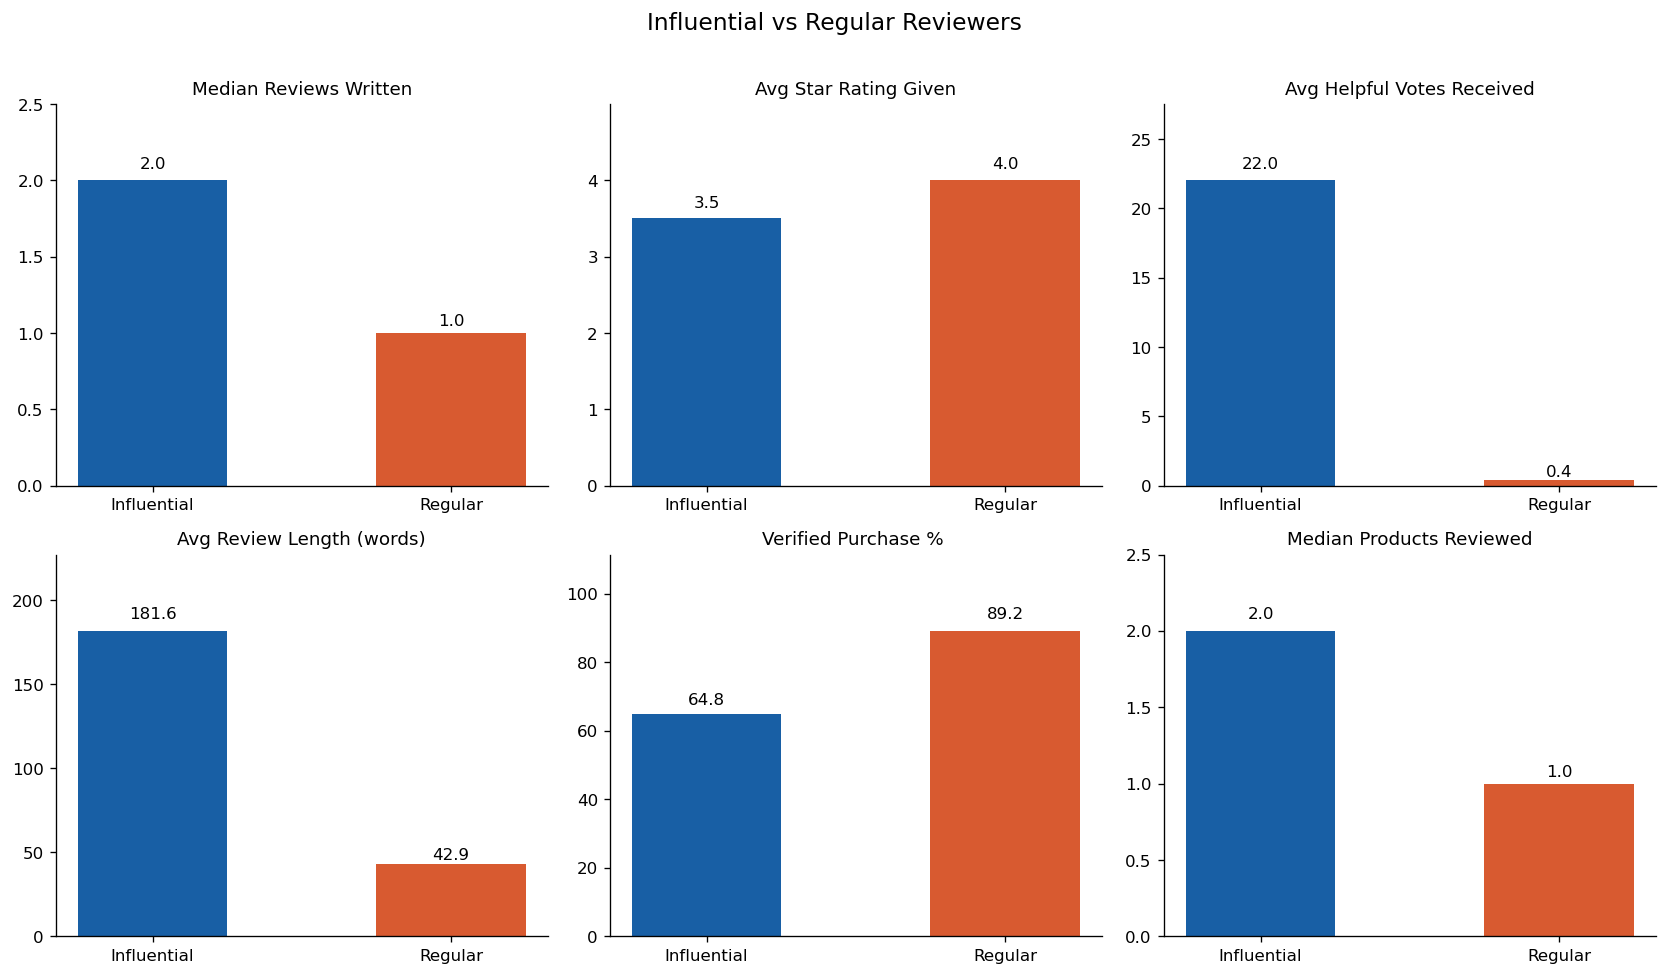

✅ 儲存：08_influential_vs_regular.png


In [16]:
inf_group = reviewer_stats[reviewer_stats['is_influential']]
reg_group = reviewer_stats[~reviewer_stats['is_influential']]

comparison = pd.DataFrame({
    'Influential': [
        inf_group['total_reviews'].median(),
        inf_group['avg_rating'].mean(),
        inf_group['avg_helpful_vote'].mean(),
        inf_group['avg_text_length'].mean(),
        inf_group['verified_ratio'].mean() * 100,
        inf_group['products_reviewed'].median(),
    ],
    'Regular': [
        reg_group['total_reviews'].median(),
        reg_group['avg_rating'].mean(),
        reg_group['avg_helpful_vote'].mean(),
        reg_group['avg_text_length'].mean(),
        reg_group['verified_ratio'].mean() * 100,
        reg_group['products_reviewed'].median(),
    ]
}, index=[
    'Median Reviews Written',
    'Avg Star Rating Given',
    'Avg Helpful Votes Received',
    'Avg Review Length (words)',
    'Verified Purchase % ',
    'Median Products Reviewed',
])

print('影響力評論者 vs 一般評論者：')
print(comparison.round(2).to_string())

# 視覺化
metrics = comparison.index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors = ['#185FA5', '#D85A30']

for i, metric in enumerate(metrics):
    vals = comparison.loc[metric]
    bars = axes[i].bar(['Influential', 'Regular'], vals.values,
                       color=colors, edgecolor='none', width=0.5)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.03,
                     f'{val:.1f}', ha='center', va='bottom', fontsize=10)
    axes[i].set_title(metric, fontsize=11)
    axes[i].set_ylim(0, vals.max() * 1.25)

plt.suptitle('Influential vs Regular Reviewers', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_influential_vs_regular.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：08_influential_vs_regular.png')

## 3. 影響力評論者的評論字數分佈

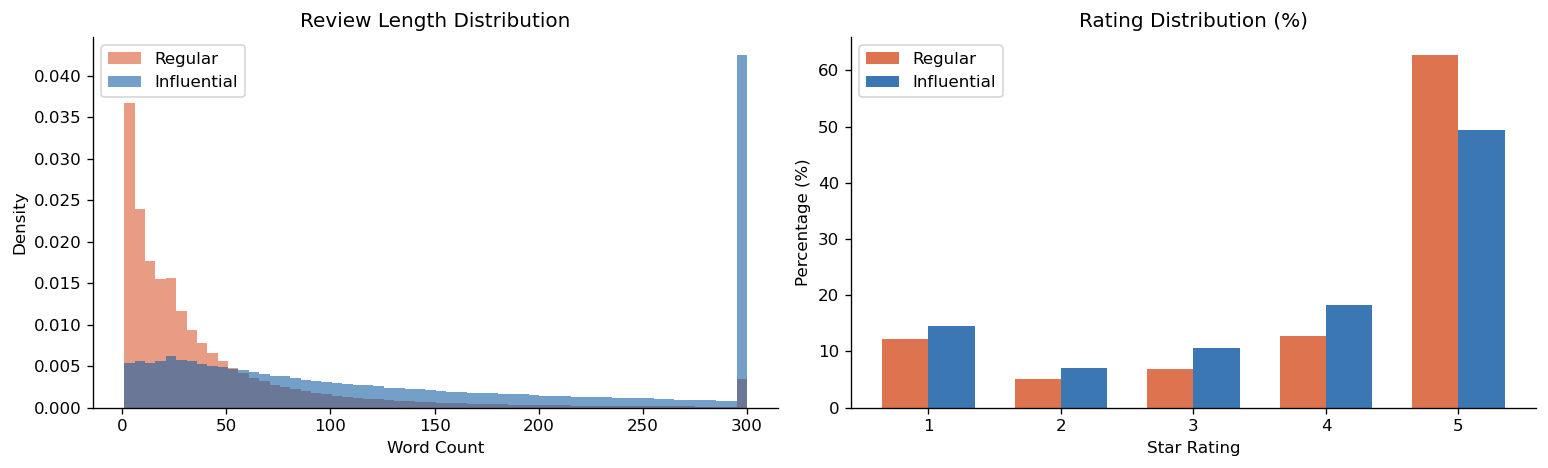

✅ 儲存：09_review_patterns.png


In [17]:
# 把 is_influential 標記加回評論層級
reviews = reviews.merge(
    reviewer_stats[['user_id', 'is_influential']],
    on='user_id', how='left'
)

inf_reviews = reviews[reviews['is_influential']]
reg_reviews = reviews[~reviews['is_influential']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 字數分佈
axes[0].hist(reg_reviews['text_length'].clip(upper=300),
             bins=60, alpha=0.6, color='#D85A30', label='Regular', density=True)
axes[0].hist(inf_reviews['text_length'].clip(upper=300),
             bins=60, alpha=0.6, color='#185FA5', label='Influential', density=True)
axes[0].set_title('Review Length Distribution', fontsize=12)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Density')
axes[0].legend()

# 星評分佈
inf_rating = inf_reviews['rating'].value_counts(normalize=True).sort_index() * 100
reg_rating = reg_reviews['rating'].value_counts(normalize=True).sort_index() * 100

x = np.arange(1, 6)
width = 0.35
axes[1].bar(x - width/2, reg_rating.values, width, label='Regular',
            color='#D85A30', alpha=0.85, edgecolor='none')
axes[1].bar(x + width/2, inf_rating.values, width, label='Influential',
            color='#185FA5', alpha=0.85, edgecolor='none')
axes[1].set_title('Rating Distribution (%)', fontsize=12)
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks(x)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_review_patterns.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：09_review_patterns.png')

## 4. 影響力評論者集中在哪些商品 & 排名是否更好

影響力評論比例 vs log_rank：r = 0.085，p = 0.0000
影響力評論數量 vs log_rank：r = -0.186，p = 0.0000

各分組的中位數 rank：
inf_group
No influential\nreviews     92121.0
Low\n(0~10%)                41761.5
Medium\n(10~30%)            76301.0
High\n(>30%)               122256.0


array([<Axes: title={'center': 'Influential Review Ratio vs log(Rank)\nr = 0.085'}, xlabel='Influential Review Ratio', ylabel='log(Rank)'>,
       <Axes: title={'center': 'Median Rank by Influential Review Ratio\n(lower rank = better sales)'}, xlabel='Influential Review Ratio Group', ylabel='Median Rank'>],
      dtype=object)

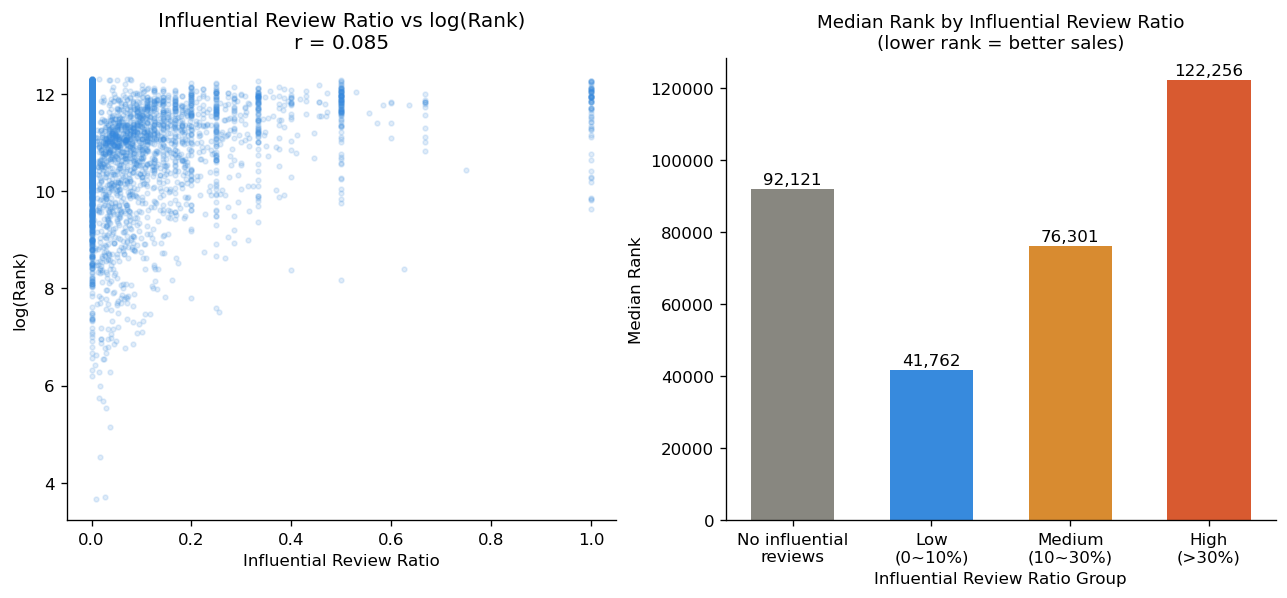

In [23]:
# 商品層級：計算影響力評論者比例和排名
product_inf = reviews.groupby('parent_asin').agg(
    total_reviews       = ('rating', 'count'),
    inf_review_count    = ('is_influential', 'sum'),
    inf_review_ratio    = ('is_influential', 'mean'),
).reset_index()

product_inf = product_inf.merge(
    meta[['parent_asin', 'log_rank', 'rank']],
    on='parent_asin', how='inner'
)

# 相關性
corr_ratio, p_ratio = stats.pearsonr(
    product_inf['inf_review_ratio'], product_inf['log_rank']
)
corr_count, p_count = stats.pearsonr(
    product_inf['inf_review_count'], product_inf['log_rank']
)

print(f'影響力評論比例 vs log_rank：r = {corr_ratio:.3f}，p = {p_ratio:.4f}')
print(f'影響力評論數量 vs log_rank：r = {corr_count:.3f}，p = {p_count:.4f}')

# 分組比較：按影響力評論比例分組（手動分，避免 qcut 重複邊界問題）
def assign_group(ratio):
    if ratio == 0:
        return 'No influential\nreviews'
    elif ratio <= 0.1:
        return 'Low\n(0~10%)'
    elif ratio <= 0.3:
        return 'Medium\n(10~30%)'
    else:
        return 'High\n(>30%)'

product_inf['inf_group'] = product_inf['inf_review_ratio'].apply(assign_group)

group_order = ['No influential\nreviews', 'Low\n(0~10%)', 'Medium\n(10~30%)', 'High\n(>30%)']
quartile_rank = product_inf.groupby('inf_group')['rank'].median().reindex(group_order)

print('\n各分組的中位數 rank：')
print(quartile_rank.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 散點圖
sample = product_inf.sample(min(5000, len(product_inf)), random_state=42)
axes[0].scatter(sample['inf_review_ratio'], sample['log_rank'],
                alpha=0.15, s=8, color='#378ADD')
axes[0].set_title(f'Influential Review Ratio vs log(Rank)\nr = {corr_ratio:.3f}', fontsize=12)
axes[0].set_xlabel('Influential Review Ratio')
axes[0].set_ylabel('log(Rank)')

# 分組柱狀圖
colors_q = ['#888780', '#378ADD', '#D88B30', '#D85A30']
bars = axes[1].bar(quartile_rank.index, quartile_rank.values,
                   color=colors_q, edgecolor='none', width=0.6)
for bar, val in zip(bars, quartile_rank.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 500,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Median Rank by Influential Review Ratio\n(lower rank = better sales)', fontsize=11)
axes[1].set_xlabel('Influential Review Ratio Group')
axes[1].set_ylabel('Median Rank')
axes

## 5. 影響力評論者畫像摘要

In [24]:
print('=' * 55)
print('影響力評論者畫像（helpful_vote ≥ 10）')
print('=' * 55)

print(f"""
人數：{n_influential:,}（佔所有評論者 {n_influential/n_total*100:.1f}%）

vs 一般評論者：
  寫了更多評論     : {inf_group['total_reviews'].median():.0f} 則（一般：{reg_group['total_reviews'].median():.0f} 則）
  評論字數更長     : {inf_group['avg_text_length'].mean():.0f} 字（一般：{reg_group['avg_text_length'].mean():.0f} 字）
  驗證購買比例更低 : {inf_group['verified_ratio'].mean()*100:.1f}%（一般：{reg_group['verified_ratio'].mean()*100:.1f}%）
  審視更多商品     : {inf_group['products_reviewed'].median():.0f} 個（一般：{reg_group['products_reviewed'].median():.0f} 個）
""")

影響力評論者畫像（helpful_vote ≥ 10）

人數：63,816（佔所有評論者 2.8%）

vs 一般評論者：
  寫了更多評論     : 2 則（一般：1 則）
  評論字數更長     : 182 字（一般：43 字）
  驗證購買比例更低 : 64.8%（一般：89.2%）
  審視更多商品     : 2 個（一般：1 個）

